In [68]:
import numpy as np
import pandas as pd


In [104]:
df=pd.read_csv("laptops.csv",encoding="latin-1")

df.columns.str.strip()
df.head()

,Manufacturer,Model Name,Category,Screen Size,Screen,CPU,RAM,Storage,GPU,Operating System,Operating System Version,Weight,Price (Euros)
0,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,NaN,1.37kg,"1339,69"
1,Apple,Macbook Air,Ultrabook,"13.3""",1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,NaN,1.34kg,"898,94"
2,HP,250 G6,Notebook,"15.6""",Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,NaN,1.86kg,"575,00"
3,Apple,MacBook Pro,Ultrabook,"15.4""",IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,NaN,1.83kg,"2537,45"
4,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,NaN,1.37kg,"1803,60"


In [82]:
df.shape
df.columns

df.isnull().sum()
df.info

<bound method DataFrame.info of      Manufacturer                           Model Name            Category  \
0           Apple                          MacBook Pro           Ultrabook   
1           Apple                          Macbook Air           Ultrabook   
2              HP                               250 G6            Notebook   
3           Apple                          MacBook Pro           Ultrabook   
4           Apple                          MacBook Pro           Ultrabook   
...           ...                                  ...                 ...   
1298       Lenovo                       Yoga 500-14ISK  2 in 1 Convertible   
1299       Lenovo                       Yoga 900-13ISK  2 in 1 Convertible   
1300       Lenovo                   IdeaPad 100S-14IBR            Notebook   
1301           HP  15-AC110nv (i7-6500U/6GB/1TB/Radeon            Notebook   
1302         Asus  X553SA-XX031T (N3050/4GB/500GB/W10)            Notebook   

     Screen Size               

In [126]:
# cleaning 
#1.making RAM column into int to perform 
df['RAM'] = df['RAM'].str.replace('GB','')
df['RAM'] = df['RAM'].astype(int)

AttributeError: Can only use .str accessor with string values!

In [127]:
#2.
df['Weight'] = df['Weight'].str.replace('kg','')
df['Weight'] = df['Weight'].str.strip()

df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

In [120]:
#3.
df.rename(columns={'Price (Euros)': 'Price'}, inplace=True)
df['Price'] = df['Price'].str.replace(',','')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


In [64]:
df.head()

,Manufacturer,Model Name,Category,Screen Size,Screen,CPU,RAM,Storage,GPU,Operating System,Operating System Version,Weight,Price,Price_k
0,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,NaN,1.37,133969,133.969
1,Apple,Macbook Air,Ultrabook,"13.3""",1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,NaN,1.34,89894,89.894
2,HP,250 G6,Notebook,"15.6""",Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,NaN,1.86,57500,57.500
3,Apple,MacBook Pro,Ultrabook,"15.4""",IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,NaN,1.83,253745,253.745
4,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,NaN,1.37,180360,180.360


0     8
1     8
2     8
3    16
4     8
Name: RAM, dtype: int64

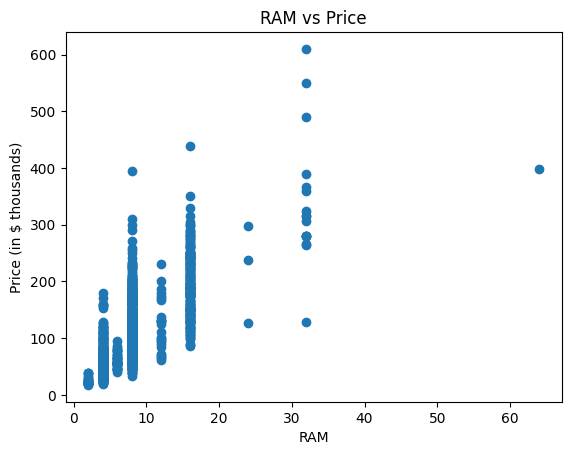

In [66]:
#4.
import matplotlib.pyplot as plt
df['Price_k'] = df['Price'] / 1000
plt.scatter(df['RAM'], df['Price_k'])
plt.xlabel("RAM")
plt.ylabel("Price (in $ thousands)")
plt.title("RAM vs Price")
plt.show()



In [93]:
df[' Storage'] = df[' Storage'].str.replace('GB','')
df[' Storage'] = df[' Storage'].str.replace('TB','000')

In [121]:
df[' Storage'].head()
df.columns.str.strip()




Index(['Manufacturer', 'Model Name', 'Category', 'Screen Size', 'Screen',
       'CPU', 'RAM', 'Storage', 'GPU', 'Operating System',
       'Operating System Version', 'Weight', 'Price', 'Total_Storage', 'SSD',
       'HDD', 'Flash'],
      dtype='object')

In [122]:
import re

def get_total_storage(x):
    nums = re.findall(r'\d+', x)
    return sum(map(int, nums))

df['Total_Storage'] = df[' Storage'].apply(get_total_storage)

In [123]:
df['SSD'] = df[' Storage'].apply(lambda x: 1 if 'SSD' in x else 0)
df['HDD'] = df[' Storage'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Flash'] = df[' Storage'].apply(lambda x: 1 if 'Flash' in x else 0)

In [124]:
df[[' Storage','Total_Storage','SSD','HDD','Flash']].head()

,Storage,Total_Storage,SSD,HDD,Flash
0,128GB SSD,128,1,0,0
1,128GB Flash Storage,128,0,0,1
2,256GB SSD,256,1,0,0
3,512GB SSD,512,1,0,0
4,256GB SSD,256,1,0,0


In [128]:
df.head()

,Manufacturer,Model Name,Category,Screen Size,Screen,CPU,RAM,Storage,GPU,Operating System,Operating System Version,Weight,Price,Total_Storage,SSD,HDD,Flash
0,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,NaN,1.37,133969,128,1,0,0
1,Apple,Macbook Air,Ultrabook,"13.3""",1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,NaN,1.34,89894,128,0,0,1
2,HP,250 G6,Notebook,"15.6""",Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,NaN,1.86,57500,256,1,0,0
3,Apple,MacBook Pro,Ultrabook,"15.4""",IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,NaN,1.83,253745,512,1,0,0
4,Apple,MacBook Pro,Ultrabook,"13.3""",IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,NaN,1.37,180360,256,1,0,0


In [132]:
df[df[' Storage'].str.contains('HDD')][[' Storage','Total_Storage','SSD','HDD','Flash']].head()

,Storage,Total_Storage,SSD,HDD,Flash
5,500GB HDD,500,0,1,0
10,500GB HDD,500,0,1,0
11,500GB HDD,500,0,1,0
18,1TB HDD,1,0,1,0
21,128GB SSD + 1TB HDD,129,1,1,0


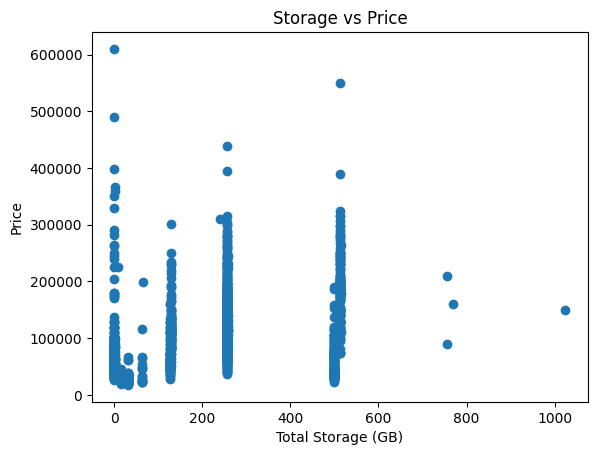

In [131]:
plt.scatter(df['Total_Storage'], df['Price'])
plt.xlabel("Total Storage (GB)")
plt.ylabel("Price")
plt.title("Storage vs Price")
plt.show()

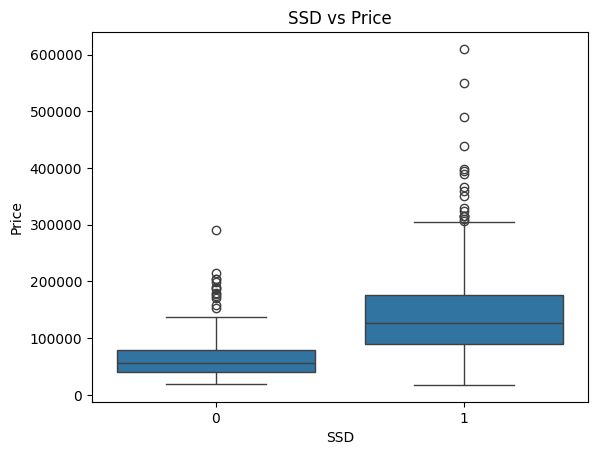

In [133]:
import seaborn as sns

sns.boxplot(x=df['SSD'], y=df['Price'])
plt.title("SSD vs Price")
plt.show()
#SSD laptops are generally more expensive

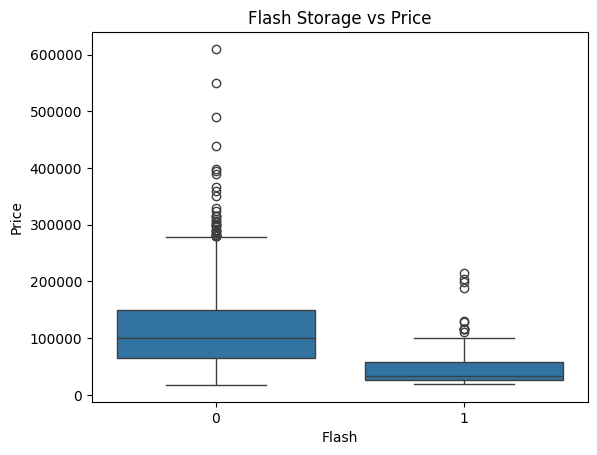

In [134]:
sns.boxplot(x=df['Flash'], y=df['Price'])
plt.title("Flash Storage vs Price")
plt.show()

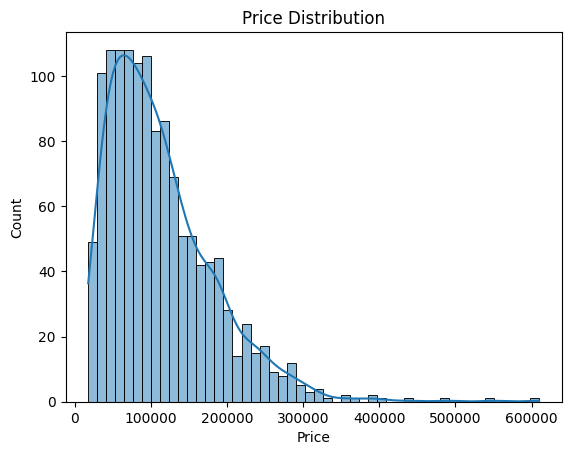

In [135]:
# Price Distribution
import seaborn as sns

sns.histplot(df['Price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

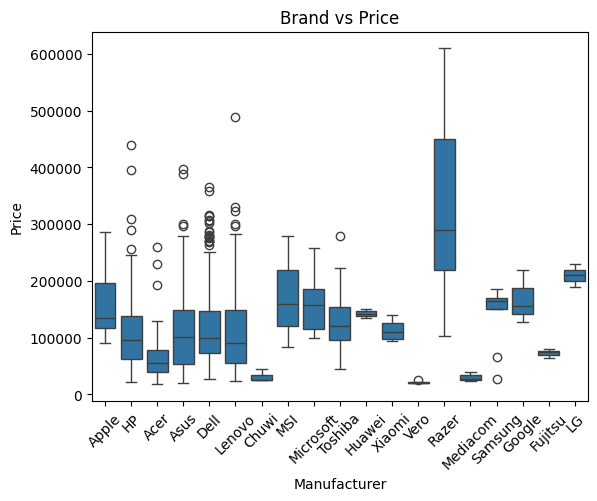

In [136]:
# Brand Impact
sns.boxplot(x=df['Manufacturer'], y=df['Price'])
plt.xticks(rotation=45)
plt.title("Brand vs Price")
plt.show()

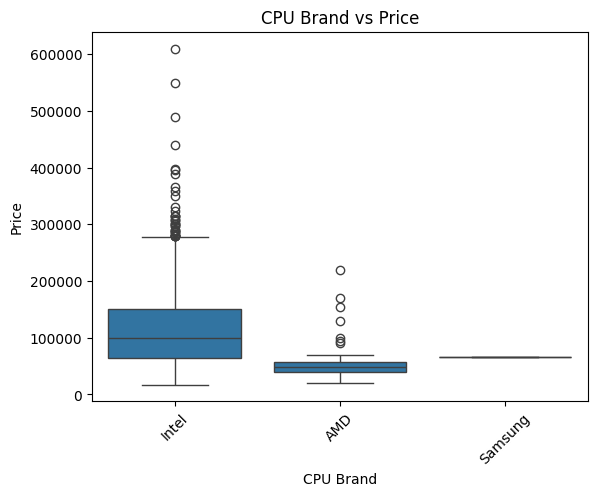

In [142]:
#cpu impact
df['CPU Brand'] = df['CPU'].apply(lambda x: x.split()[0])

sns.boxplot(x=df['CPU Brand'], y=df['Price'])
plt.xticks(rotation=45)
plt.title("CPU Brand vs Price")
plt.show()

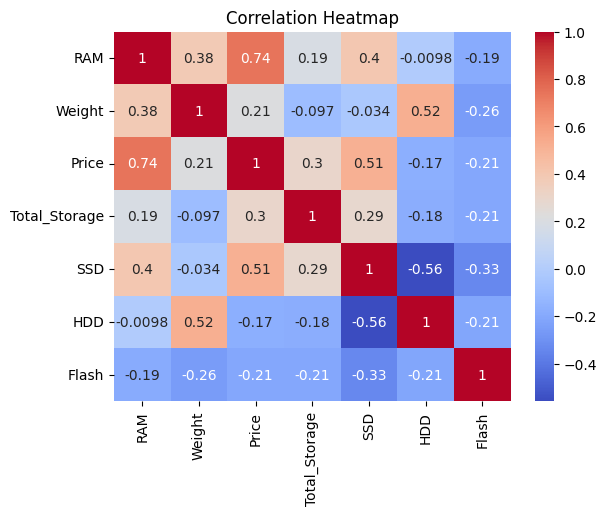

In [140]:
#CORRELATION HEATMAP
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [144]:
def cpu_category(x):
    if 'i7' in x or 'Ryzen 7' in x:
        return 'High End'
    elif 'i5' in x or 'Ryzen 5' in x:
        return 'Mid Range'
    elif 'i3' in x or 'Ryzen 3' in x:
        return 'Low End'
    else:
        return 'Budget'

df['CPU Category'] = df['CPU'].apply(cpu_category)


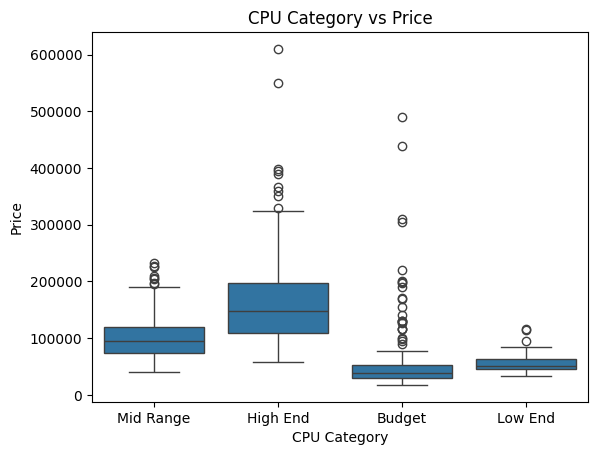

In [145]:
sns.boxplot(x=df['CPU Category'], y=df['Price'])
plt.title("CPU Category vs Price")
plt.show()

In [ ]:
#When you can answer:

#What affects price most?
#Which brand is expensive?
#Which storage is cheaper?
#How data is distributed?


In [ ]:
#Feature Engeenering

In [146]:
df['Price_per_GB'] = df['Price'] / df['Total_Storage']

In [147]:
df['Performance'] = df['RAM'] * 2 + df['SSD'] * 50

In [148]:
df['Value'] = df['Performance'] / df['Price']

In [149]:
def weight_cat(x):
    if x < 1.5:
        return 'Light'
    elif x < 2.5:
        return 'Medium'
    else:
        return 'Heavy'

df['Weight Category'] = df['Weight'].apply(weight_cat)

In [150]:
df.sort_values(by='Value', ascending=False).head(10)

,Manufacturer,Model Name,Category,Screen Size,Screen,CPU,RAM,Storage,GPU,Operating System,...,SSD,HDD,Flash,CPU Brand,CPU Type,CPU Category,Price_per_GB,Performance,Value,Weight Category
1215,Acer,C740-C9QX (3205U/2GB/32GB/Chrome,Netbook,"11.6""",1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2,32GB SSD,Intel HD Graphics,Chrome OS,...,1,0,0,Intel,Celeron Dual,Budget,543.750000,54,0.003103,Light
1102,Acer,Chromebook 15,Notebook,"15.6""",1366x768,Intel Celeron Dual Core 3205U 1.5GHz,4,16GB SSD,Intel HD Graphics,Chrome OS,...,1,0,0,Intel,Celeron Dual,Budget,1306.250000,58,0.002775,Medium
290,Acer,Chromebook C910-C2ST,Notebook,"15.6""",1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2,16GB SSD,Intel HD Graphics,Chrome OS,...,1,0,0,Intel,Celeron Dual,Budget,1243.750000,54,0.002714,Medium
67,HP,Stream 14-AX040wm,Notebook,"14.0""",1366x768,Intel Celeron Dual Core N3060 1.6GHz,4,32GB SSD,Intel HD Graphics 400,Windows,...,1,0,0,Intel,Celeron Dual,Budget,715.625000,58,0.002533,Light
575,Mediacom,SmartBook 141,Notebook,"14.0""",Full HD 1920x1080,Intel Atom x5-Z8350 1.44GHz,4,32GB SSD,Intel HD Graphics,Windows,...,1,0,0,Intel,Atom x5-Z8350,Budget,778.125000,58,0.002329,Light
504,Lenovo,Chromebook N23,Netbook,"11.6""",1366x768,Intel Celeron Dual Core N3060 1.6GHz,4,16GB SSD,Intel HD Graphics 400,Chrome OS,...,1,0,0,Intel,Celeron Dual,Budget,1656.250000,58,0.002189,Light
992,Lenovo,V110-15IAP (N3350/4GB/128GB/No,Notebook,"15.6""",1366x768,Intel Celeron Dual Core N3350 1.1GHz,4,128GB SSD,Intel HD Graphics 500,No OS,...,1,0,0,Intel,Celeron Dual,Budget,211.421875,58,0.002143,Medium
127,Asus,E402WA-GA007T (E2-6110/4GB/64GB/W10,Notebook,"14.0""",1366x768,AMD E-Series 6110 1.5GHz,4,64GB SSD,AMD Radeon R2,Windows,...,1,0,0,AMD,E-Series 6110,Budget,434.359375,58,0.002086,Medium
429,Mediacom,FlexBook Edge,2 in 1 Convertible,"11.6""",IPS Panel Full HD / Touchscreen 1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4,32GB SSD,Intel HD Graphics 500,Windows,...,1,0,0,Intel,Celeron Dual,Budget,934.375000,58,0.001940,Light
850,HP,250 G6,Notebook,"15.6""",1366x768,Intel Celeron Dual Core N3060 1.6GHz,4,128GB SSD,Intel HD Graphics 400,No OS,...,1,0,0,Intel,Celeron Dual,Budget,233.593750,58,0.001940,Medium


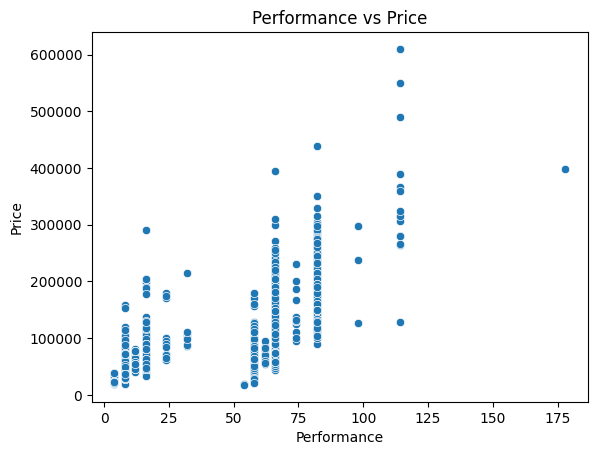

In [151]:
sns.scatterplot(x=df['Performance'], y=df['Price'])
plt.title("Performance vs Price")
plt.show()

In [152]:
df.sort_values(by='Value', ascending=False)[['Manufacturer','RAM','Total_Storage','Price','Value']].head(10)

,Manufacturer,RAM,Total_Storage,Price,Value
1215,Acer,2,32,17400,0.003103
1102,Acer,4,16,20900,0.002775
290,Acer,2,16,19900,0.002714
67,HP,4,32,22900,0.002533
575,Mediacom,4,32,24900,0.002329
504,Lenovo,4,16,26500,0.002189
992,Lenovo,4,128,27062,0.002143
127,Asus,4,64,27799,0.002086
429,Mediacom,4,32,29900,0.001940
850,HP,4,128,29900,0.001940


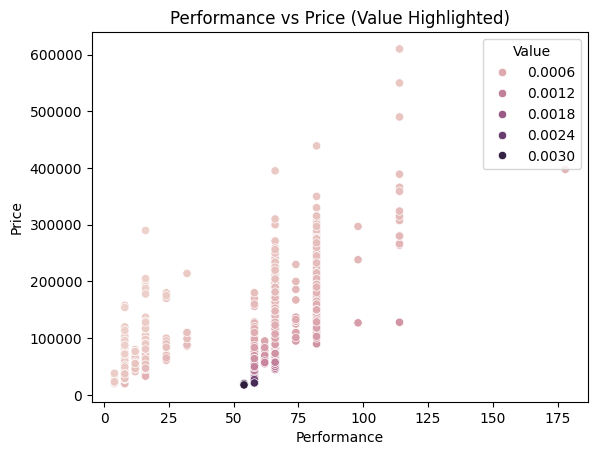

In [153]:
sns.scatterplot(x=df['Performance'], y=df['Price'], hue=df['Value'])
plt.title("Performance vs Price (Value Highlighted)")
plt.show()

In [ ]:
# Machine_learning _model

In [154]:
X = df[['RAM', 'Weight', 'Total_Storage', 'SSD', 'HDD', 'Flash']]
y = df['Price']

In [155]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [156]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [157]:
y_pred = model.predict(X_test)

In [158]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 24846.589355257078
R2 Score: 0.6767596953119945


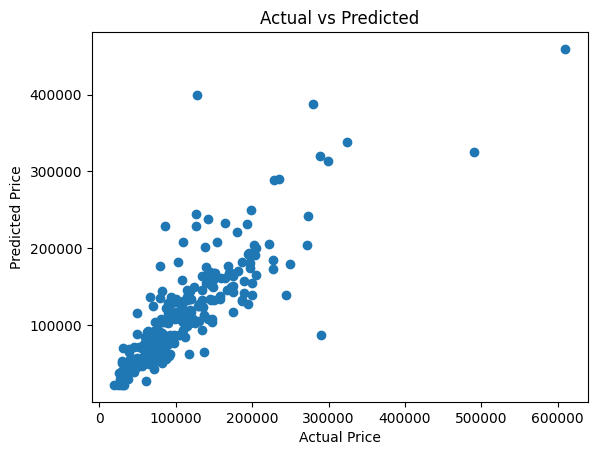

In [159]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

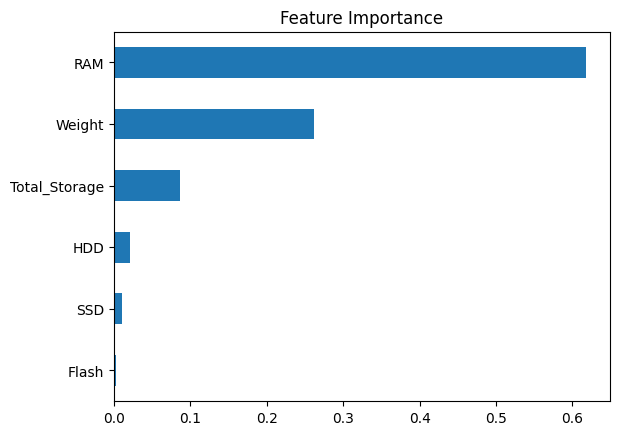

In [160]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()